# **Labb 2 – CNN Interpretability**

**Model:** ResNet18 (default ImageNet weights, default CAM layer: `layer4`)

**Classes tested:**
- Doberman (ImageNet class 236)
- Toucan (ImageNet class 96)
- Siamese cat (ImageNet class 284)

For each class I ran LayerCAM on one positive example (an image that actually contains the class) and one negative example (an image that does not). The goal is to see what regions the model pays attention to, and whether that attention makes sense.

In [ ]:
import torch
import json
import matplotlib.pyplot as plt

from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.methods import LayerCAM
from torchcam.utils import overlay_mask

# Load pretrained ResNet18 model
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

# Load ImageNet labels
with open("imagenet_class_index.json", "r") as f:
    class_index = json.load(f)

# Returns the top predicted class name and its confidence score
def predict_class(output_tensor):
    probs = output_tensor.squeeze()
    top_idx = int(probs.argmax())
    synset_id, class_name = class_index[str(top_idx)]

    return class_name, float(probs[top_idx])

def run_image(image_path, target_class_idx=None):
    # Load image and apply preprocessing pipeline
    img = decode_image(image_path)
    input_tensor = preprocess(img)

    #Run LayerCAM and generate CAM heatmap for the target class
    with LayerCAM(model) as cam_extractor:
        out = model(input_tensor.unsqueeze(0))
        probs = out.squeeze(0).softmax(0)

        # use given target class, otherwise use the model's top prediction
        if target_class_idx is not None:
            pred_idx = target_class_idx
        else:
            pred_idx = out.squeeze(0).argmax().item()

        activation_map = cam_extractor(pred_idx, out)

    class_name, confidence = predict_class(probs)
    class_name_target = class_index[str(pred_idx)][1]

    print("Image:", image_path)
    print("Model prediction:", class_name, f"({confidence:.3f})")
    print("CAM target class:", class_name_target)

    # Overlay heatmap on top of the original image (alpha= 50% transparency)
    result = overlay_mask(
        to_pil_image(img),
        to_pil_image(activation_map[0].squeeze(0), mode='F'),
        alpha=0.5
    )

    # Plot images side by side, original with CAM overlay
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(to_pil_image(img))
    axes[0].axis("off")
    axes[0].set_title("Original")
    axes[1].imshow(result)
    axes[1].axis("off")
    axes[1].set_title(f"LayerCAM - target: {class_name_target}")
    plt.tight_layout()
    plt.show()

---
## Class 1: Doberman (class 236)

Doberman - POSITIVE
Image: doberman.jpg
Model prediction: Doberman (0.990)
CAM target class: Doberman


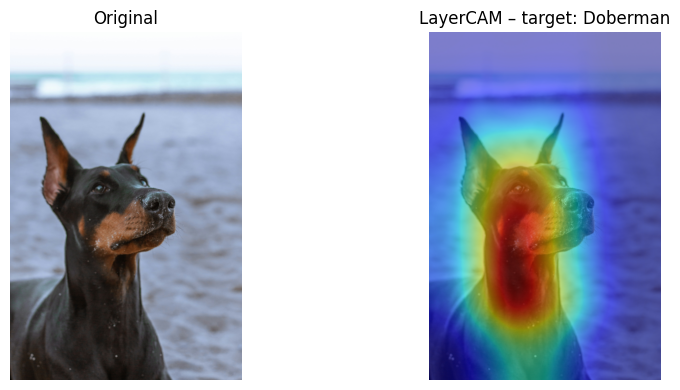

In [27]:
# Positive example - doberman image, CAM for doberman
print("Doberman - POSITIVE")
run_image("doberman.jpg", target_class_idx=236)

Doberman - NEGATIVE (toucan image)
Image: toucan.jpg
Model prediction: toucan (0.999)
CAM target class: Doberman


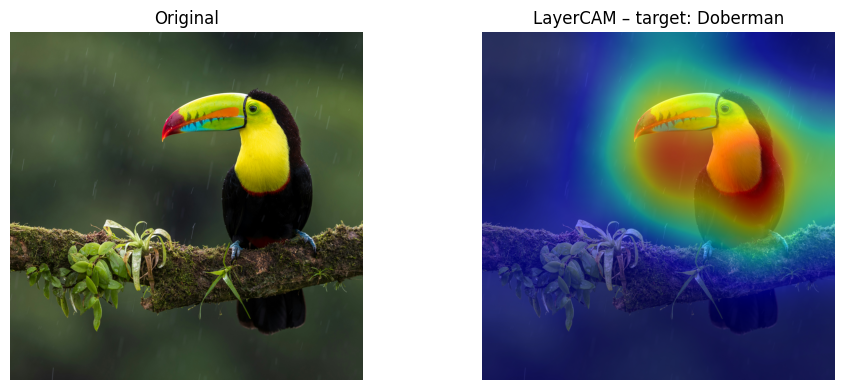

In [28]:
# Negative example - toucan image, CAM for doberman
print("Doberman - NEGATIVE (toucan image)")
run_image("toucan.jpg", target_class_idx=236)

### Analysis: Doberman

* Positive: The CAM map lights up quite strongly around the dog's chest, neck and head area. Looking at the red/orange regions, the model seems to be focusing on the dark coat with the brown markings along the chest and face. This makes sense, those colour contrasts and the head shape are probably the most obvious things that set a Doberman apart from other breeds.

* Negative: When running the Doberman CAM on the toucan image, I noticed that the activation actually concentrates on the toucan's yellow chest and beak region. My guess is that the yellow/tan colouring on the toucan's breast is somehow triggering the same feature detectors that look for the brown markings on a Doberman. It's interesting that the model is responding to a colour similarity even though the animals are completely different. The activation is also more spread out compared to the positive example, which suggests the model isn't very confident about what it's looking at.

---
## Class 2: Toucan (class 96)

Toucan - POSITIVE
Image: toucan.jpg
Model prediction: toucan (0.999)
CAM target class: toucan


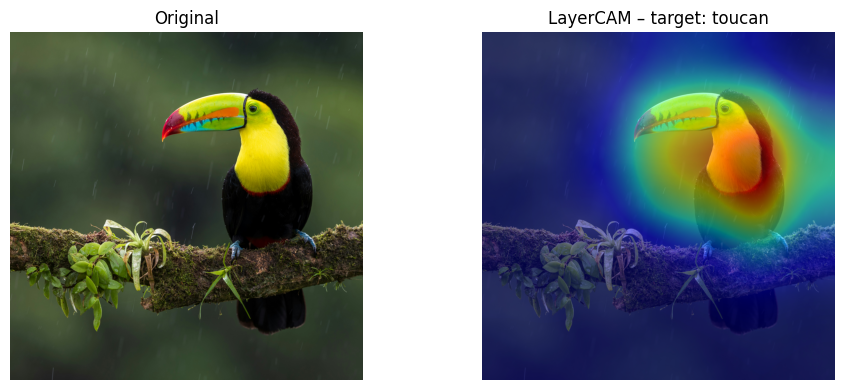

In [29]:
# Positive example - toucan image, CAM for toucan
print("Toucan - POSITIVE")
run_image("toucan.jpg", target_class_idx=96)

Toucan - NEGATIVE (siamese image)
Image: siamese.jpg
Model prediction: Siamese_cat (0.912)
CAM target class: toucan


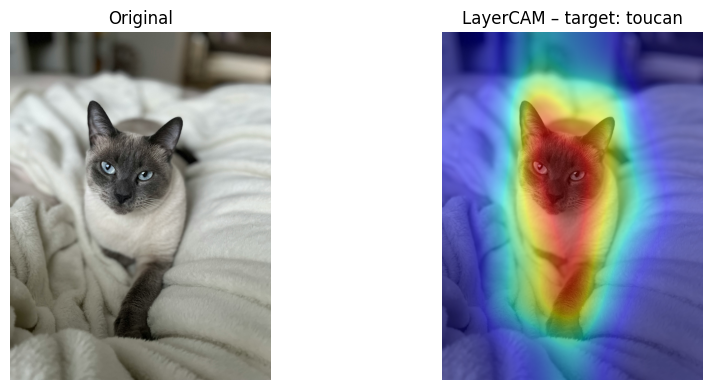

In [30]:
# Negative example - siamese image, CAM for toucan
print("Toucan - NEGATIVE (siamese image)")
run_image("siamese.jpg", target_class_idx=96)

### Analysis: Toucan

* Positive: Here the CAM result is pretty clear, the activation focuses directly on the beak and the yellow chest, which are exactly the most distinctive features of a toucan. The background is mostly blue/cold which means the model is largely ignoring it. So at least for this one it looks like the model picked up on the right things.

* Negative: On the Siamese cat image with toucan as the target class, the activation is quite spread out and doesn't focus on anything special. That makes sense, there's nothing in the image that looks like a toucan beak or chest so the model has nowhere to focus its attention. The map ends up looking more or less random across the cat's body.

---
## Class 3: Siamese cat (class 284)

Siamese - POSITIVE
Image: siamese.jpg
Model prediction: Siamese_cat (0.912)
CAM target class: Siamese_cat


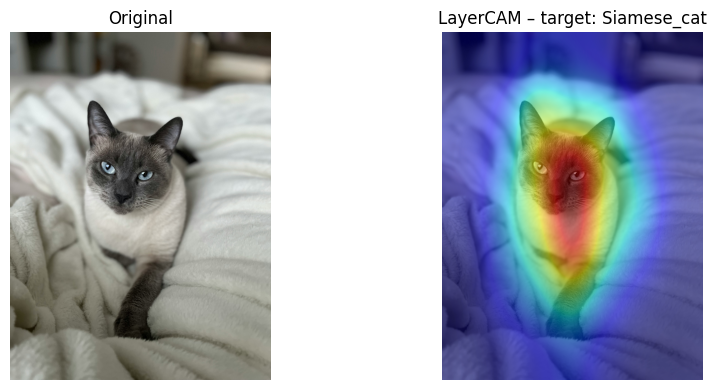

In [31]:
# Positive example - siamese image, CAM for siamese
print("Siamese - POSITIVE")
run_image("siamese.jpg", target_class_idx=284)

Siamese - NEGATIVE (doberman image)
Image: doberman.jpg
Model prediction: Doberman (0.990)
CAM target class: Siamese_cat


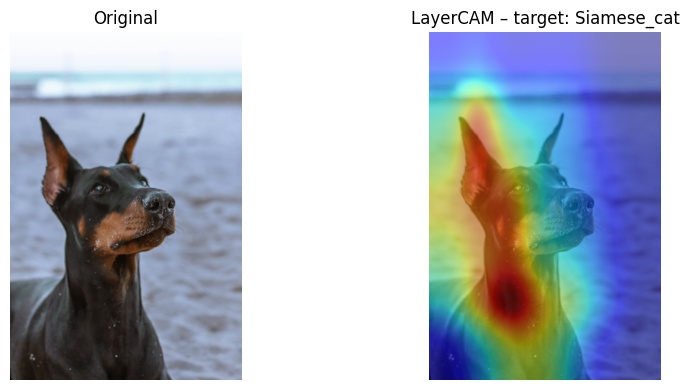

In [32]:
# Negative example - doberman image, CAM for siamese
print("Siamese - NEGATIVE (doberman image)")
run_image("doberman.jpg", target_class_idx=284)

### Analysis: Siamese cat

* Positive: The activation concentrates heavily on the cat's face, especially around the eyes and nose. Siamese cats have a pretty distinctive dark facial mask with light blue eyes, so it seems like the model has learned to focus on the face rather than the body or background.

* Negative: On the Doberman image with Siamese as the target class, the activation lands somewhere around the dog's chest and lower neck instead of the face. I think this happens because dogs and cats share some low-level features like fur texture and general body shape, so the model still finds something to activate on. The confidence for Siamese is very low though, so it's not actually confusing the two.

---
## Logit analysis

To get a better sense of what the model is doing internally, I looked at the top-5 softmax probabilities for the Siamese cat image. The idea is to see whether the other high-scoring classes are semantically related to Siamese, or completely random.

In [ ]:
# Load the Siamese image and preprocess it the same way as before
img = decode_image("siamese.jpg")
input_tensor = preprocess(img)

# Run model without tracking gradients since we only need the output
with torch.no_grad():
    out = model(input_tensor.unsqueeze(0))

# Get top 5 class probabilities
probs = out.squeeze(0).softmax(0)
top5_vals, top5_idx = torch.topk(probs, 5)

print("Top-5 predictions for siamese.jpg:")
print(f"{'Rank':<6} {'Class name':<25} {'Confidence':>10}")
print("--------------------------------------------")
for rank, (prob, idx) in enumerate(zip(top5_vals.tolist(), top5_idx.tolist()), 1):
    name = class_index[str(idx)][1]
    print(f"{rank:<6} {name:<25} {prob*100:>9.2f}%")

Top-5 predictions for siamese.jpg:
Rank   Class name                Confidence
--------------------------------------------
1      Siamese_cat                   91.19%
2      Egyptian_cat                   4.65%
3      tabby                          1.41%
4      lynx                           0.79%
5      paper_towel                    0.28%


### Analysis - logits

The top-5 predictions for the Siamese cat image are almost all different cat breeds (for example Egyptian cat and tabby). This makes sense because cats of different breeds share similiar visual features. (fur texture, ear shape, eye position and whiskers) The model's `layer4` feature detectors fire on all of them, just to different degrees.

The Siamese class ends up on top probably because the specific colouring (dark face, lighter body) matches that breed most closely. The non-zero probabilities for the other cat classes show that the decision boundary between similar classes isn't very sharp, which makes sense given how visually similar breeds can be. Not sure why it predicted paper towel in the end, but maybe the very light colors in the image made it predict that.

---
## Summary

In this assignment I used LayerCAM with ResNet18 to see which regions of an image the model focuses on when classifying different ImageNet classes.

For positive examples the results were generally quite convincing. The model highlighted the Doberman's markings, the toucan's beak, and the Siamese cat's face, which are all the features you would expect a human to look at too.

For negative examples the activations were weaker and more spread out, which is expected since the target class isn't in the image. The most interesting case was the Doberman CAM on the toucan image, where the model seemed to activate on the toucan's yellow chest because of colour similarity to Doberman markings. (a good example of how feature detectors can fire for the wrong reasons)

The logit analysis supported this by showing that the top-5 predictions for the Siamese image were almost all other cat breeds, which makes sense since they share a lot of the same visual features anyway.